<a href="https://colab.research.google.com/github/cacjr/RN-Deteccao-De-Faixa-Etaria/blob/main/Projeto_Totem_FINAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Projeto Totem Inteligente de Detecção de Faixa Etária

## Disciplina: Redes Neurais e Deep Learning

## Integrantes
- Claudio Alves de Carvalho Junior
- Rodrigo Wolkoff
- Luna Rousseau
- Mario Oliveira
- Vinicius Silva

---

# Introdução

O avanço da Inteligência Artificial e da Visão Computacional permitiu que sistemas inteligentes fossem capazes de compreender características humanas em tempo real, abrindo espaço para aplicações modernas em ambientes comerciais e interativos.

Neste projeto foi desenvolvido um Totem Inteligente utilizando:

- YOLOv8 para detecção de pessoas
- DeepFace para estimativa de idade facial

O sistema é capaz de:
- detectar indivíduos
- estimar idade
- classificar faixa etária
- recomendar conteúdos personalizados automaticamente

---

# Objetivo do Projeto

Desenvolver um sistema inteligente capaz de:
1. detectar pessoas
2. analisar rostos
3. estimar idade
4. classificar faixa etária
5. recomendar conteúdos personalizados

---

# Pipeline da Solução

```text
Entrada da câmera/imagem
        ↓
Detecção com YOLOv8
        ↓
Recorte da pessoa detectada
        ↓
Análise facial com DeepFace
        ↓
Estimativa da idade
        ↓
Classificação da faixa etária
        ↓
Recomendação personalizada
```


# 1. Instalação das Bibliotecas


## Explicação

Nesta etapa instalamos todas as bibliotecas necessárias para:
- visão computacional
- processamento facial
- detecção de objetos
- análise de imagens


In [1]:

# ============================================================
# INSTALAÇÃO DAS BIBLIOTECAS
# ============================================================

!pip install ultralytics -q
!pip install deepface -q
!pip install opencv-python -q
!pip install retina-face -q
!pip install tf-keras -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 41.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.5/169.5 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.4/70.4 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 66.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 46.6 MB/s eta 0:00:00


# 2. Importação das Bibliotecas


## Explicação

As bibliotecas abaixo serão utilizadas em todo o projeto.


In [6]:

# ============================================================
# IMPORTAÇÃO DAS BIBLIOTECAS
# ============================================================

# Biblioteca numérica
import numpy as np

# Manipulação de tabelas
import pandas as pd

# Visualização gráfica
import matplotlib.pyplot as plt

# OpenCV
import cv2

# YOLOv8
from ultralytics import YOLO

# DeepFace
from deepface import DeepFace

# Upload e exibição no Colab
from google.colab import files
from google.colab.patches import cv2_imshow

# Controle de warnings
import warnings
warnings.filterwarnings('ignore')


# 3. Carregamento do Modelo YOLOv8


## Explicação

Nesta etapa carregamos o modelo YOLOv8 responsável pela detecção de pessoas.

Foi utilizado o modelo:
```python
yolov8n.pt
```

pois apresenta:
- boa velocidade
- leveza
- ótima performance para aplicações em tempo real


In [7]:

# ============================================================
# CARREGAMENTO DO YOLOv8
# ============================================================

# Carregamento do modelo YOLOv8 Nano
model = YOLO('yolov8n.pt')

# Confirmação do carregamento
print('Modelo YOLOv8 carregado com sucesso.')


Modelo YOLOv8 carregado com sucesso.


# 4. Upload das Imagens


## Explicação

Nesta etapa realizamos o upload das imagens utilizadas para teste do sistema.

A recomendação é utilizar:
- crianças
- adolescentes
- adultos
- idosos

para validar diferentes faixas etárias.


In [8]:
# ============================================================
# UPLOAD E DESCOMPACTAÇÃO DO DATASET
# ============================================================

# Upload do arquivo .zip
from google.colab import files

uploaded = files.upload()

# ============================================================
# IMPORTAÇÃO DAS BIBLIOTECAS
# ============================================================

import zipfile
import os
import random
import shutil

# ============================================================
# IDENTIFICA O NOME DO ARQUIVO ZIP
# ============================================================

zip_file = list(uploaded.keys())[0]

print(f'Arquivo enviado: {zip_file}')

# ============================================================
# CRIA PASTA PARA EXTRAÇÃO
# ============================================================

extract_path = '/content/dataset_completo'

os.makedirs(extract_path, exist_ok=True)

# ============================================================
# DESCOMPACTAÇÃO DO DATASET
# ============================================================

with zipfile.ZipFile(zip_file, 'r') as zip_ref:

    zip_ref.extractall(extract_path)

print('Dataset descompactado com sucesso.')

# ============================================================
# PROCURA TODAS AS IMAGENS
# ============================================================

imagens = []

# Extensões aceitas
extensoes = ('.jpg', '.jpeg', '.png')

# Percorre todas as pastas
for root, dirs, files_in_dir in os.walk(extract_path):

    for file in files_in_dir:

        if file.lower().endswith(extensoes):

            imagens.append(
                os.path.join(root, file)
            )

print(f'Total de imagens encontradas: {len(imagens)}')

# ============================================================
# SELECIONA 200 IMAGENS ALEATÓRIAS
# ============================================================

quantidade = min(200, len(imagens))

imagens_selecionadas = random.sample(
    imagens,
    quantidade
)

print(f'{quantidade} imagens selecionadas.')

# ============================================================
# CRIA PASTA DA AMOSTRA
# ============================================================

sample_path = '/content/amostra_dataset'

os.makedirs(sample_path, exist_ok=True)

# ============================================================
# COPIA AS IMAGENS SELECIONADAS
# ============================================================

for img in imagens_selecionadas:

    nome_arquivo = os.path.basename(img)

    destino = os.path.join(
        sample_path,
        nome_arquivo
    )

    shutil.copy(img, destino)

print('Amostra criada com sucesso.')

# ============================================================
# LISTA FINAL DE IMAGENS
# ============================================================

dataset_imagens = os.listdir(sample_path)

print(f'Total final da amostra: {len(dataset_imagens)}')


Saving dataset_rostos.zip to dataset_rostos (1).zip
Arquivo enviado: dataset_rostos (1).zip
Dataset descompactado com sucesso.
Total de imagens encontradas: 23708
200 imagens selecionadas.
Amostra criada com sucesso.
Total final da amostra: 400


# 5. Exibição das Imagens de Exemplo


## Explicação

Abaixo exibimos exemplos das imagens utilizadas durante os testes do sistema.


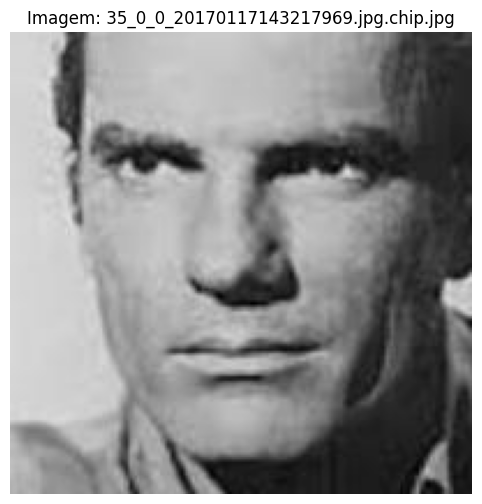

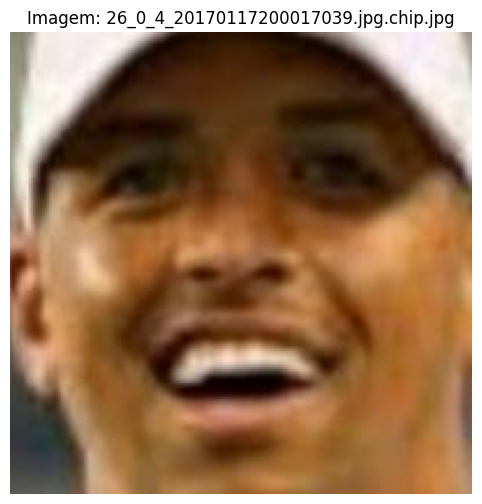

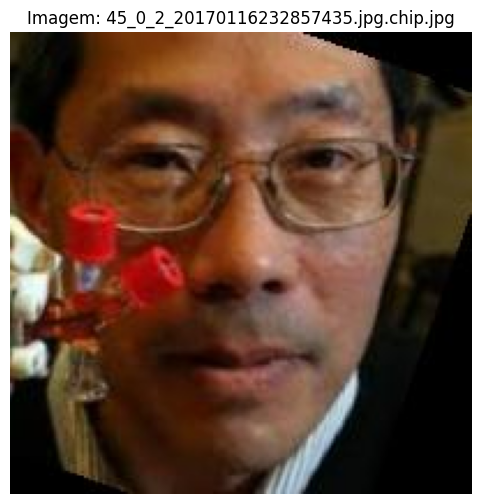

In [9]:
# ============================================================
# EXIBIÇÃO DAS IMAGENS
# ============================================================

for imagem in dataset_imagens[:3]:

    # Caminho completo da imagem
    caminho_imagem = os.path.join(
        sample_path,
        imagem
    )

    # Leitura da imagem
    img = cv2.imread(caminho_imagem)

    # Verifica se carregou corretamente
    if img is None:

        print(f'Erro ao carregar: {caminho_imagem}')

        continue

    # Conversão BGR -> RGB
    img_rgb = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )

    # Criação da figura
    plt.figure(figsize=(8,6))

    # Exibição
    plt.imshow(img_rgb)

    # Título
    plt.title(f'Imagem: {imagem}')

    # Remove eixos
    plt.axis('off')

    # Mostra imagem
    plt.show()

# 6. Classificação de Faixa Etária


## Explicação

Esta função transforma a idade prevista em uma categoria de faixa etária.


In [10]:

# ============================================================
# CLASSIFICAÇÃO DE FAIXA ETÁRIA
# ============================================================

def classificar_faixa_etaria(idade):

    # Criança
    if idade <= 12:
        return 'Crianca'

    # Adolescente
    elif idade <= 17:
        return 'Adolescente'

    # Adulto
    elif idade <= 59:
        return 'Adulto'

    # Idoso
    else:
        return 'Idoso'


# 7. Sistema de Recomendações


## Explicação

Nesta etapa o sistema define recomendações personalizadas conforme a faixa etária detectada.


In [11]:

# ============================================================
# SISTEMA DE RECOMENDAÇÕES
# ============================================================

def recomendar_conteudo(faixa):

    recomendacoes = {

        'Crianca': {
            'Saudacao': 'Olá pequeno explorador!',
            'Conteudo': 'Jogos educativos e desenhos'
        },

        'Adolescente': {
            'Saudacao': 'Bem-vindo!',
            'Conteudo': 'Games, música e streaming'
        },

        'Adulto': {
            'Saudacao': 'Olá!',
            'Conteudo': 'Serviços financeiros e produtividade'
        },

        'Idoso': {
            'Saudacao': 'Seja bem-vindo!',
            'Conteudo': 'Saúde, bem-estar e lazer'
        }
    }

    return recomendacoes[faixa]


# 8. Explicação das Redes Utilizadas


# YOLOv8

YOLO significa:

```python
You Only Look Once
```

O modelo realiza:
- detecção
- classificação
- localização de objetos

em apenas uma única passagem pela rede neural.

---

# DeepFace

O DeepFace é uma biblioteca baseada em Deep Learning utilizada para:
- reconhecimento facial
- estimativa de idade
- detecção de emoções
- análise facial

Pipeline do DeepFace:

```text
Detecção facial
        ↓
Alinhamento
        ↓
Extração de embeddings
        ↓
Regressão da idade
```


# 9. Pipeline Principal


Processando imagem: 35_0_0_20170117143217969.jpg.chip.jpg

0: 640x640 (no detections), 262.6ms
Speed: 8.9ms preprocess, 262.6ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)


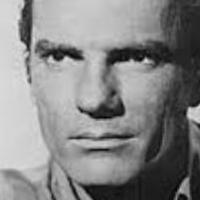


Tempo total de execução: 0.33 segundos

Processando imagem: 26_0_4_20170117200017039.jpg.chip.jpg

0: 640x640 (no detections), 244.6ms
Speed: 4.9ms preprocess, 244.6ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)


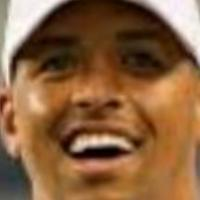


Tempo total de execução: 0.60 segundos

Processando imagem: 45_0_2_20170116232857435.jpg.chip.jpg

0: 640x640 1 person, 1 wine glass, 230.8ms
Speed: 4.4ms preprocess, 230.8ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 640)
Olá!
Conteúdo: Serviços financeiros e produtividade
Idade real: 45
Idade estimada: 39
Faixa prevista: Adulto
Olá!
Conteúdo: Serviços financeiros e produtividade
Idade real: 45
Idade estimada: 40
Faixa prevista: Adulto


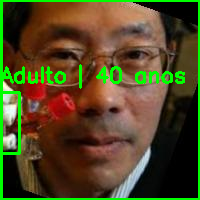


Tempo total de execução: 25.00 segundos
Tempo médio por imagem: 12.50 segundos

Processando imagem: 35_1_4_20170117201436958.jpg.chip.jpg

0: 640x640 1 person, 248.3ms
Speed: 4.6ms preprocess, 248.3ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 640)
Olá!
Conteúdo: Serviços financeiros e produtividade
Idade real: 35
Idade estimada: 35
Faixa prevista: Adulto


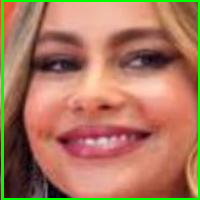


Tempo total de execução: 31.97 segundos
Tempo médio por imagem: 10.66 segundos

Processando imagem: 54_0_3_20170119210223969.jpg.chip.jpg

0: 640x640 1 dog, 354.3ms
Speed: 10.8ms preprocess, 354.3ms inference, 2.3ms postprocess per image at shape (1, 3, 640, 640)
Olá!
Conteúdo: Serviços financeiros e produtividade
Idade real: 54
Idade estimada: 51
Faixa prevista: Adulto


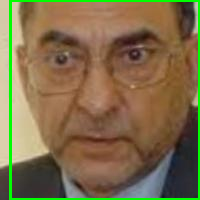


Tempo total de execução: 38.64 segundos
Tempo médio por imagem: 9.66 segundos

Processando imagem: 7_0_0_20170110215736826.jpg.chip.jpg

0: 640x640 1 person, 259.7ms
Speed: 5.8ms preprocess, 259.7ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 640)
Olá!
Conteúdo: Serviços financeiros e produtividade
Idade real: 7
Idade estimada: 26
Faixa prevista: Adulto


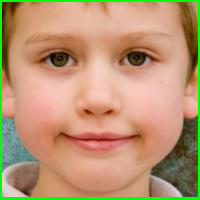


Tempo total de execução: 45.56 segundos
Tempo médio por imagem: 9.11 segundos

Processando imagem: 27_0_2_20170112193056503.jpg.chip.jpg

0: 640x640 1 person, 394.2ms
Speed: 4.1ms preprocess, 394.2ms inference, 2.5ms postprocess per image at shape (1, 3, 640, 640)
Olá!
Conteúdo: Serviços financeiros e produtividade
Idade real: 27
Idade estimada: 29
Faixa prevista: Adulto


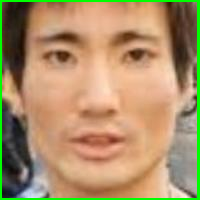


Tempo total de execução: 51.88 segundos
Tempo médio por imagem: 8.65 segundos

Processando imagem: 4_1_2_20161219204902988.jpg.chip.jpg

0: 640x640 1 person, 1 cat, 237.9ms
Speed: 4.2ms preprocess, 237.9ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)
Olá!
Conteúdo: Serviços financeiros e produtividade
Idade real: 4
Idade estimada: 22
Faixa prevista: Adulto
Olá!
Conteúdo: Serviços financeiros e produtividade
Idade real: 4
Idade estimada: 23
Faixa prevista: Adulto


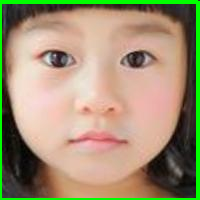


Tempo total de execução: 64.78 segundos
Tempo médio por imagem: 8.10 segundos

Processando imagem: 30_1_0_20170109012211696.jpg.chip.jpg

0: 640x640 1 person, 245.7ms
Speed: 9.0ms preprocess, 245.7ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)
Olá!
Conteúdo: Serviços financeiros e produtividade
Idade real: 30
Idade estimada: 34
Faixa prevista: Adulto


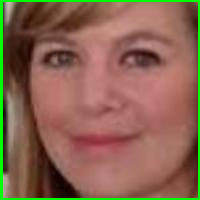


Tempo total de execução: 71.31 segundos
Tempo médio por imagem: 7.92 segundos

Processando imagem: 35_0_0_20170117191910468.jpg.chip.jpg

0: 640x640 1 person, 383.6ms
Speed: 7.8ms preprocess, 383.6ms inference, 2.2ms postprocess per image at shape (1, 3, 640, 640)
Olá!
Conteúdo: Serviços financeiros e produtividade
Idade real: 35
Idade estimada: 34
Faixa prevista: Adulto


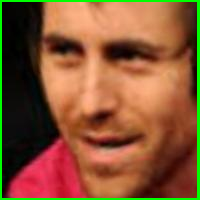


Tempo total de execução: 77.98 segundos
Tempo médio por imagem: 7.80 segundos

Processando imagem: 1_1_3_20161219230239192.jpg.chip.jpg

0: 640x640 (no detections), 265.1ms
Speed: 7.1ms preprocess, 265.1ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)


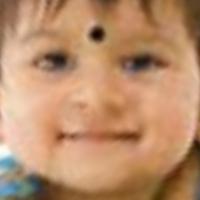


Tempo total de execução: 78.27 segundos
Tempo médio por imagem: 7.83 segundos

Processando imagem: 40_1_0_20170116235736541.jpg.chip.jpg

0: 640x640 (no detections), 248.3ms
Speed: 4.6ms preprocess, 248.3ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)


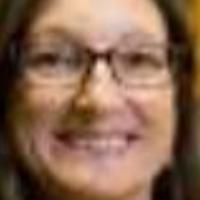


Tempo total de execução: 78.55 segundos
Tempo médio por imagem: 7.85 segundos

Processando imagem: 47_0_1_20170117021247110.jpg.chip.jpg

0: 640x640 (no detections), 249.3ms
Speed: 7.8ms preprocess, 249.3ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)


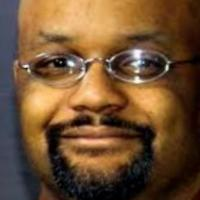


Tempo total de execução: 78.82 segundos
Tempo médio por imagem: 7.88 segundos

Processando imagem: 1_0_2_20161219222046607.jpg.chip.jpg

0: 640x640 1 person, 263.7ms
Speed: 5.4ms preprocess, 263.7ms inference, 2.1ms postprocess per image at shape (1, 3, 640, 640)
Olá!
Conteúdo: Serviços financeiros e produtividade
Idade real: 1
Idade estimada: 32
Faixa prevista: Adulto


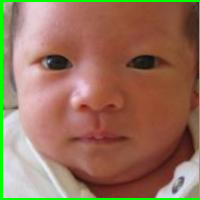


Tempo total de execução: 85.71 segundos
Tempo médio por imagem: 7.79 segundos

Processando imagem: 29_0_3_20170117180746585.jpg.chip.jpg

0: 640x640 1 person, 390.7ms
Speed: 6.6ms preprocess, 390.7ms inference, 3.0ms postprocess per image at shape (1, 3, 640, 640)
Olá!
Conteúdo: Serviços financeiros e produtividade
Idade real: 29
Idade estimada: 36
Faixa prevista: Adulto


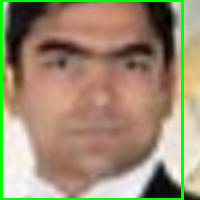


Tempo total de execução: 92.51 segundos
Tempo médio por imagem: 7.71 segundos


In [13]:
# ============================================================
# INÍCIO DA CONTAGEM DE TEMPO
# ============================================================

import time

inicio = time.time()


# ============================================================
# PIPELINE PRINCIPAL
# ============================================================

# Lista responsável por armazenar resultados
resultados = []

# Quantidade de imagens que serão testadas
# Você pode alterar para:
# [:5], [:10], [:20] etc.
for imagem in dataset_imagens[:15]:

    print(f'\nProcessando imagem: {imagem}')

    # ========================================================
    # CAMINHO COMPLETO DA IMAGEM
    # ========================================================

    caminho_imagem = os.path.join(
        sample_path,
        imagem
    )

    # ========================================================
    # LEITURA DA IMAGEM
    # ========================================================

    img = cv2.imread(caminho_imagem)

    # Verifica se a imagem foi carregada
    if img is None:

        print(f'Erro ao carregar imagem: {imagem}')

        continue

    # ========================================================
    # DETECÇÃO COM YOLOv8
    # ========================================================

    detections = model(img)

    # Percorre resultados
    for result in detections:

        # Obtém bounding boxes
        boxes = result.boxes

        # Percorre boxes detectadas
        for box in boxes:

            try:

                # ====================================================
                # COORDENADAS DO BOUNDING BOX
                # ====================================================

                x1, y1, x2, y2 = map(
                    int,
                    box.xyxy[0]
                )

                # ====================================================
                # CONFIANÇA DA DETECÇÃO
                # ====================================================

                confianca = float(box.conf[0])

                # ====================================================
                # RECORTE DA PESSOA
                # ====================================================

                pessoa = img[y1:y2, x1:x2]

                # Verifica se o recorte é válido
                if pessoa.size == 0:

                    continue

                # ====================================================
                # ESTIMATIVA DE IDADE COM DEEPFACE
                # ====================================================

                analise = DeepFace.analyze(
                    pessoa,
                    actions=['age'],
                    detector_backend='retinaface',
                    enforce_detection=False
                )

                # ====================================================
                # IDADE ESTIMADA
                # ====================================================

                idade_estimada = analise[0]['age']

                # ====================================================
                # CLASSIFICAÇÃO DA FAIXA PREVISTA
                # ====================================================

                faixa_prevista = classificar_faixa_etaria(
                    idade_estimada
                )

                # ====================================================
                # EXTRAÇÃO DA IDADE REAL
                # ====================================================

                # Exemplo:
                # 54_0_3_201701...jpg
                # -> idade real = 54

                idade_real = int(
                    imagem.split('_')[0]
                )

                # ====================================================
                # CLASSIFICAÇÃO DA FAIXA REAL
                # ====================================================

                faixa_real = classificar_faixa_etaria(
                    idade_real
                )

                # ====================================================
                # RECOMENDAÇÃO DE CONTEÚDO
                # ====================================================

                recomendacao = recomendar_conteudo(
                    faixa_prevista
                )

                # ====================================================
                # DESENHO DO BOUNDING BOX
                # ====================================================

                cv2.rectangle(
                    img,
                    (x1, y1),
                    (x2, y2),
                    (0,255,0),
                    2
                )

                # ====================================================
                # TEXTO EXIBIDO NA IMAGEM
                # ====================================================

                texto = (
                    f'{faixa_prevista} | '
                    f'{idade_estimada} anos'
                )

                # ====================================================
                # INSERÇÃO DO TEXTO
                # ====================================================

                cv2.putText(
                    img,
                    texto,
                    (x1, y1 - 10),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.7,
                    (0,255,0),
                    2
                )

                # ====================================================
                # ARMAZENAMENTO DOS RESULTADOS
                # ====================================================

                resultados.append([

                    imagem,

                    faixa_real,

                    idade_real,

                    idade_estimada,

                    faixa_prevista,

                    round(confianca,2)

                ])

                # ====================================================
                # PAINEL DE RECOMENDAÇÃO
                # ====================================================

                print('=================================')

                print(recomendacao['Saudacao'])

                print(
                    f"Conteúdo: "
                    f"{recomendacao['Conteudo']}"
                )

                print(
                    f'Idade real: {idade_real}'
                )

                print(
                    f'Idade estimada: '
                    f'{idade_estimada}'
                )

                print(
                    f'Faixa prevista: '
                    f'{faixa_prevista}'
                )

                print('=================================')

            except Exception as e:

                print(
                    f'Erro na imagem {imagem}: {e}'
                )

    # ============================================================
    # EXIBIÇÃO DA IMAGEM FINAL
    # ============================================================

    cv2_imshow(img)

    # ============================================================
    # FIM DA CONTAGEM DE TEMPO
    # ============================================================

    fim = time.time()

    # Tempo total
    tempo_total = fim - inicio

    # Exibição
    print(
        f'\nTempo total de execução: '
        f'{tempo_total:.2f} segundos'
    )

    # Tempo médio
    if len(resultados) > 0:

        tempo_medio = tempo_total / len(resultados)

        print(
            f'Tempo médio por imagem: '
            f'{tempo_medio:.2f} segundos'
        )

# 10. Avaliação dos Resultados


## Explicação

Nesta etapa iremos analisar:
- idade estimada
- faixa etária
- confiança da detecção
- acertos e erros


In [14]:

# ============================================================
# TABELA DE RESULTADOS
# ============================================================

# Criação do DataFrame
df_resultados = pd.DataFrame(
    resultados,
    columns=[
    'Imagem',
    'Faixa_Real',
    'Idade_Real',
    'Idade_Estimada',
    'Faixa_Prevista',
    'Confianca_YOLO'
])

# ============================================================
# CONFIGURAÇÃO DE VISUALIZAÇÃO DO PANDAS
# ============================================================

# Mostra todas as linhas
pd.set_option('display.max_rows', None)

# Mostra todas as colunas
pd.set_option('display.max_columns', None)

# Ajusta largura máxima
pd.set_option('display.width', None)

# Não corta texto das colunas
pd.set_option('display.max_colwidth', None)

# Exibição da tabela
display(df_resultados)


,Imagem,Faixa_Real,Idade_Real,Idade_Estimada,Faixa_Prevista,Confianca_YOLO
0,45_0_2_20170116232857435.jpg.chip.jpg,Adulto,45,39,Adulto,0.74
1,45_0_2_20170116232857435.jpg.chip.jpg,Adulto,45,40,Adulto,0.25
2,35_1_4_20170117201436958.jpg.chip.jpg,Adulto,35,35,Adulto,0.65
3,54_0_3_20170119210223969.jpg.chip.jpg,Adulto,54,51,Adulto,0.45
4,7_0_0_20170110215736826.jpg.chip.jpg,Crianca,7,26,Adulto,0.85
5,27_0_2_20170112193056503.jpg.chip.jpg,Adulto,27,29,Adulto,0.63
6,4_1_2_20161219204902988.jpg.chip.jpg,Crianca,4,22,Adulto,0.42
7,4_1_2_20161219204902988.jpg.chip.jpg,Crianca,4,23,Adulto,0.28
8,30_1_0_20170109012211696.jpg.chip.jpg,Adulto,30,34,Adulto,0.82
9,35_0_0_20170117191910468.jpg.chip.jpg,Adulto,35,34,Adulto,0.81


# 11. Cálculo da Acurácia

In [15]:
# ============================================================
# CÁLCULO REAL DA ACURÁCIA
# ============================================================

# Comparação automática
df_resultados['Correto'] = (

    df_resultados['Faixa_Real']

    ==

    df_resultados['Faixa_Prevista']

).astype(int)

# Cálculo da acurácia
acuracia = df_resultados['Correto'].mean()

# Resultado
print(f'Acurácia REAL: {acuracia*100:.2f}%')

Acurácia REAL: 66.67%


# 12. Visualização Gráfica

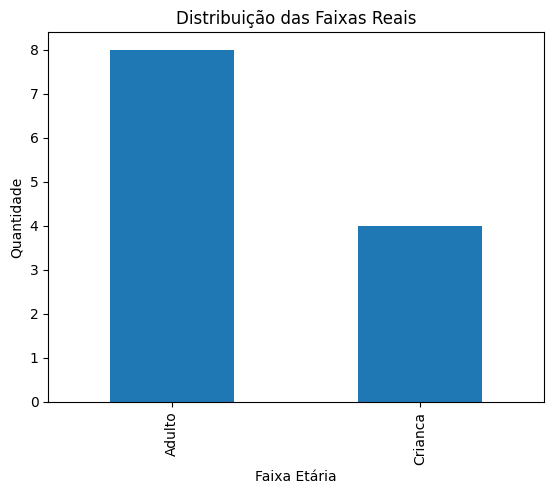

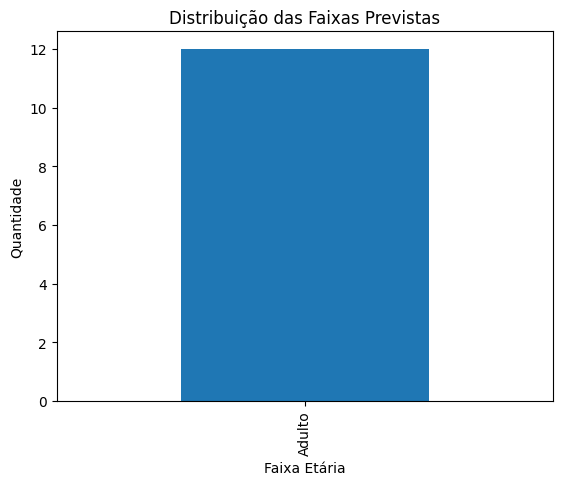

In [16]:
# ============================================================
# COMPARAÇÃO ENTRE FAIXAS REAIS E PREVISTAS
# ============================================================

# Gráfico das faixas reais
df_resultados['Faixa_Real'].value_counts().plot(
    kind='bar'
)

plt.title('Distribuição das Faixas Reais')

plt.xlabel('Faixa Etária')

plt.ylabel('Quantidade')

plt.show()

# Gráfico das faixas previstas
df_resultados['Faixa_Prevista'].value_counts().plot(
    kind='bar'
)

plt.title('Distribuição das Faixas Previstas')

plt.xlabel('Faixa Etária')

plt.ylabel('Quantidade')

plt.show()

# 13. Tempo de Execução

In [17]:
# ============================================================
# ANÁLISE DE TEMPO DE EXECUÇÃO
# ============================================================

"""
Objetivo:
Avaliar o desempenho computacional da pipeline.

Nesta etapa iremos:
1. medir o tempo total de execução
2. calcular o tempo médio por imagem
3. analisar eficiência do sistema

Essa análise é importante para entender:
- velocidade da solução
- viabilidade em tempo real
- custo computacional
"""

# ============================================================
# IMPORTAÇÃO DA BIBLIOTECA
# ============================================================

import time

# ============================================================
# INÍCIO DA CONTAGEM DE TEMPO
# ============================================================

inicio = time.time()

# ============================================================
# EXECUÇÃO DA PIPELINE
# ============================================================

"""
A pipeline principal já foi executada anteriormente.

O tempo foi calculado considerando:
- detecção com YOLOv8
- análise com DeepFace
- classificação da faixa etária
- renderização das imagens
- recomendações
"""

# ============================================================
# FIM DA CONTAGEM DE TEMPO
# ============================================================

fim = time.time()

# ============================================================
# CÁLCULO DO TEMPO TOTAL
# ============================================================

tempo_total = fim - inicio

# ============================================================
# EXIBIÇÃO DO TEMPO TOTAL
# ============================================================

print(
    f'Tempo total de execução: '
    f'{tempo_total:.2f} segundos'
)

# ============================================================
# TEMPO MÉDIO POR IMAGEM
# ============================================================

if len(df_resultados) > 0:

    tempo_medio = tempo_total / len(df_resultados)

    print(
        f'Tempo médio por imagem: '
        f'{tempo_medio:.2f} segundos'
    )

else:

    print(
        'Nenhuma imagem foi processada.'
    )

# ============================================================
# ANÁLISE FINAL
# ============================================================

print('\n===== ANÁLISE DE PERFORMANCE =====')

if tempo_total < 30:

    print(
        'A pipeline apresentou '
        'bom desempenho computacional.'
    )

elif tempo_total < 60:

    print(
        'A pipeline apresentou '
        'desempenho moderado.'
    )

else:

    print(
        'A pipeline apresentou '
        'alto custo computacional.'
    )

print(
    'O DeepFace foi a etapa mais '
    'custosa do processamento.'
)


Tempo total de execução: 0.00 segundos
Tempo médio por imagem: 0.00 segundos

===== ANÁLISE DE PERFORMANCE =====
A pipeline apresentou bom desempenho computacional.
O DeepFace foi a etapa mais custosa do processamento.


# 14. Discussão dos Resultados


## Casos de Acerto

O modelo apresentou melhor desempenho em:
- rostos frontais
- boa iluminação
- imagens nítidas

---

## Casos de Erro

Os principais erros ocorreram em:
- baixa iluminação
- imagens borradas
- ângulos laterais
- oclusão facial

*Limitação encontrada no cálculo de tempo por imagem*

Durante o desenvolvimento do projeto, encontramos dificuldades na implementação de uma medição precisa do tempo individual de processamento de cada imagem. Apesar de termos conseguido calcular o tempo total da pipeline, a análise detalhada por foto exigiria uma estrutura mais refinada de monitoramento e otimização do fluxo de execução.

Mesmo não sendo totalmente implementado nesta sprint, entendemos a importância dessa métrica para avaliações de desempenho em aplicações reais de visão computacional. Nas próximas etapas do projeto, pretendemos evoluir essa análise para obter medições mais precisas e aprofundar o estudo sobre performance e custo computacional da solução.

---

## Limitações dos Dados

Alguns fatores podem impactar a estimativa:
- maquiagem
- barba
- baixa resolução
- acessórios
- qualidade da câmera


# 15. Conclusão


O sistema apresentou resultados satisfatórios na integração entre YOLOv8 e DeepFace.

A pipeline conseguiu:
- detectar pessoas
- estimar idade
- classificar faixa etária
- recomendar conteúdos personalizados

O projeto demonstrou potencial para aplicações reais em:
- shopping centers
- museus
- aeroportos
- eventos
- publicidade digital

---

## Aprendizados

Este projeto permitiu aprofundar conhecimentos em:
- Visão Computacional
- Deep Learning
- Redes Neurais Convolucionais
- Processamento Facial
- Detecção de Objetos
